In [38]:
import datetime as dt

import numpy as np
import pandas as pd

from plotly import express as px
from plotly import graph_objects as go
from plotly.subplots import make_subplots


#### 2.a: Pick government securities from a country. The country selected should be one of the countries from your group so that you can fit a Nelson-Siegel mode

Load gilts table with clean price and yield of a day.

Data Soource: [dividenddata](https://www.dividenddata.co.uk/uk-gilts-prices-yields.py) cross-checked with [Trading Economics](https://tradingeconomics.com/united-kingdom/government-bond-yield) and [Matket Watch](https://www.marketwatch.com/tools/markets/bonds/a-z/U)'s Gilt section.

In [63]:
gilts_df = pd.read_csv('task2_gilt_20250116.csv')

gilts_df['Maturity Date'] = pd.to_datetime(gilts_df['Maturity Date'])
gilts_df['Time To Maturity'] = (gilts_df['Maturity Date'] - pd.Timestamp(dt.date.today())).dt.days / 365.
gilts_df['Yield (%)'] /= 100.0 

ttm = 'TimeToMaturity'
prx = 'Price'
yld = 'Yield'
gilts_df = gilts_df.rename(
    columns={
        'Maturity Date': 'Maturity', 
        'Time To Maturity': ttm, 
        'Price (£)': prx, 
        'Yield (%)': yld
    }
)
gilts_df.iloc[10:15]

,EPIC,Name,Coupon,Maturity,TimeToMaturity,Price,Yield
10,TG27,1 1/4% Treasury Gilt 2027,1.25%,2027-07-22,2.509589,93.07,0.04180
11,TR27,4 1/4% Treasury Gilt 2027,4.25%,2027-12-07,2.887671,100.14,0.04197
12,TN28,0 1/8% Treasury Gilt 2028,0.125%,2028-01-31,3.038356,88.78,0.04086
13,TE28,4 3/8% Treasury Gilt 2028,4.375%,2028-03-07,3.136986,99.97,0.04384
14,TS28,4 1/2% Treasury Gilt 2028,4.5%,2028-06-07,3.389041,100.44,0.04358


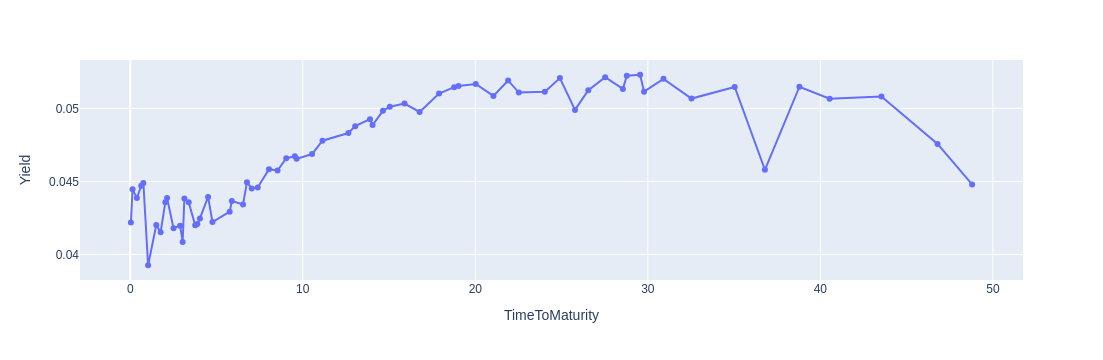

In [64]:
px.line(data_frame=gilts_df, x=ttm, y='Yield', markers=True)

### 2.b:  Be sure to pick maturities ranging from short-term to long-term (e.g. 6 month maturity to 20 or 30 year maturities).

We shorten up the list upto 30 years of time to maturity for convience, and the trades rarely occur beyond that hence the true price is less trustful anyway.</br>
On the front end, we also cut down gilts less then a half year to mature - under true market circumstance, near expiry bonds are subject to repo financing and base rates dynamics rather than curve hence are rather noises in our curve modeling purposes.

In [65]:
gilts_df = gilts_df[(gilts_df[ttm] <= 30) & (gilts_df[ttm] >= 0.5)].reset_index(drop=True)
gilts_df.iloc[[0,1,2,-3,-2,-1]]

,EPIC,Name,Coupon,Maturity,TimeToMaturity,Price,Yield
0,T25,2% Treasury Gilt 2025,2%,2025-09-07,0.638356,98.46,0.04471
1,TY25,3 1/2% Treasury Gilt 2025,3.5%,2025-10-22,0.761644,99.26,0.04490
2,T26,0 1/8% Treasury Gilt 2026,0.125%,2026-01-30,1.035616,96.17,0.03926
51,T53,3 3/4% Treasury Gilt 2053,3.75%,2053-10-22,28.780822,78.18,0.05224
52,T54,4 3/8% Treasury Gilt 2054,4.375%,2054-07-31,29.553425,87.20,0.05231
53,TR54,1 5/8% Treasury Gilt 2054,1.625%,2054-10-22,29.780822,46.94,0.05115


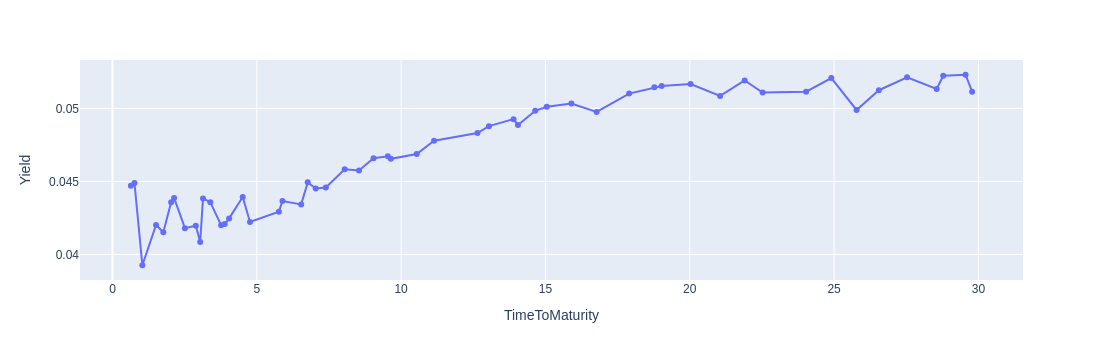

In [67]:
px.line(data_frame=gilts_df, x=ttm, y=yld, markers=True)

## 2.c Fit a Nelson-Siegel model.

In [78]:
from typing import Dict, List
import scipy as sp

In [111]:
gilts_input_df = gilts_df.set_index(ttm)
gilts_input_df.iloc[[0,1,2,-3,-2,-1]]

,EPIC,Name,Coupon,Maturity,Price,Yield
TimeToMaturity,,,,,,
0.638356,T25,2% Treasury Gilt 2025,2%,2025-09-07,98.46,0.04471
0.761644,TY25,3 1/2% Treasury Gilt 2025,3.5%,2025-10-22,99.26,0.04490
1.035616,T26,0 1/8% Treasury Gilt 2026,0.125%,2026-01-30,96.17,0.03926
28.780822,T53,3 3/4% Treasury Gilt 2053,3.75%,2053-10-22,78.18,0.05224
29.553425,T54,4 3/8% Treasury Gilt 2054,4.375%,2054-07-31,87.20,0.05231
29.780822,TR54,1 5/8% Treasury Gilt 2054,1.625%,2054-10-22,46.94,0.05115


In [126]:
def get_nelson_seigel_rate(tenor: float, parameters: Dict[str, float]) -> float:
    """ Calculate rate of the tenor via Nelson-Siegel model with given parameters.

    r(tenor) = b0 + b1 * (1 - exp(-tenor/lambda))/(tenor/lambda) + b2 * ((1 - exp(-tenor/lambda))/(tenor/lambda) - exp(-tenor/lambda))
    """
    b0 = parameters['b0']
    b1 = parameters['b1']
    b2 = parameters['b2']
    lamda = parameters['lamda'] 

    x = tenor/lamda
    decay: float = np.exp(-x)
    concaved: float = (1. - decay)/x

    r = b0 + b1 * concaved + b2 * (concaved - decay)
    return r.item()


def get_nelson_siegel_model_rates_over_tenors(tenors: List, parameters_arr: np.ndarray):
    rates = []
    for tn in tenors:
        r_tn = get_nelson_seigel_rate(
            tenor = tn, 
            parameters = dict(b0=parameters_arr[0], b1=parameters_arr[1], b2=parameters_arr[2], lamda=parameters_arr[3])
        )
        rates.append(r_tn)

    return rates


def minimise_l2_gilts_vs_model(parameters_arr: np.ndarray) -> float:
    rates = get_nelson_siegel_model_rates_over_tenors(gilts_input_df.index.to_list(), parameters_arr)

    return np.sqrt(np.mean(np.square(gilts_input_df[yld].values - np.array(rates)).mean()))


example_parameters = dict(b0=0.04, b1= 0.015, b2= 0.01, lamda=3.)
print(f'Nelson-Siegel model yield at 10yr tenor with parameters: {get_nelson_seigel_rate(tenor=10., parameters = example_parameters)}')
print(f'L2 SME difference between Market vs Model yields: {minimise_l2_gilts_vs_model(np.array(list(example_parameters.values())))}')

Nelson-Siegel model yield at 10yr tenor with parameters: 0.04687570511642308
L2 SME difference between Market vs Model yields: 0.007609407690071908


In [127]:
# Given that gilts_df[[ttm, yld]] is the table of time_to_maturity and yield, 
# We can find the least-square fitted parameters of the nelson_siegel curve model via scipy optimiser in sp.optimize.minimize().

opt_res = sp.optimize.minimize(
    fun = minimise_l2_gilts_vs_model,
    x0 = np.array([0.04, 0.015, 0.01, 3.0])
)
opt_res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0009179749306209922
        x: [ 5.510e-02 -9.440e-03 -2.684e-02  2.374e+00]
      nit: 26
      jac: [-5.069e-06 -1.774e-06 -8.800e-07  5.166e-09]
 hess_inv: [[ 1.721e-02 -2.864e-02  9.406e-03  6.118e+00]
            [-2.864e-02  1.072e-01 -1.604e-01 -1.755e+01]
            [ 9.406e-03 -1.604e-01  4.086e-01  2.561e+01]
            [ 6.118e+00 -1.755e+01  2.561e+01  3.751e+03]]
     nfev: 175
     njev: 35

In [128]:
parameters_opt_arr = opt_res.x
parameters_opt_arr

array([ 0.05509824, -0.0094397 , -0.02684195,  2.37444033])

In [129]:
yld_NS: List[float] = get_nelson_siegel_model_rates_over_tenors(gilts_input_df.index.to_list(), parameters_opt_arr)
yld_Market_vs_NS = pd.DataFrame({f'{yld}.Market': gilts_input_df[yld].to_list(), f'{yld}.NS': yld_NS}, index=gilts_input_df.index)
yld_Market_vs_NS.iloc[[0,1,2,-3,-2,-1]]

,Yield.Market,Yield.NS
TimeToMaturity,,
0.638356,0.04471,0.043799
0.761644,0.04490,0.043537
1.035616,0.03926,0.043048
28.780822,0.05224,0.052105
29.553425,0.05231,0.052183
29.780822,0.05115,0.052206


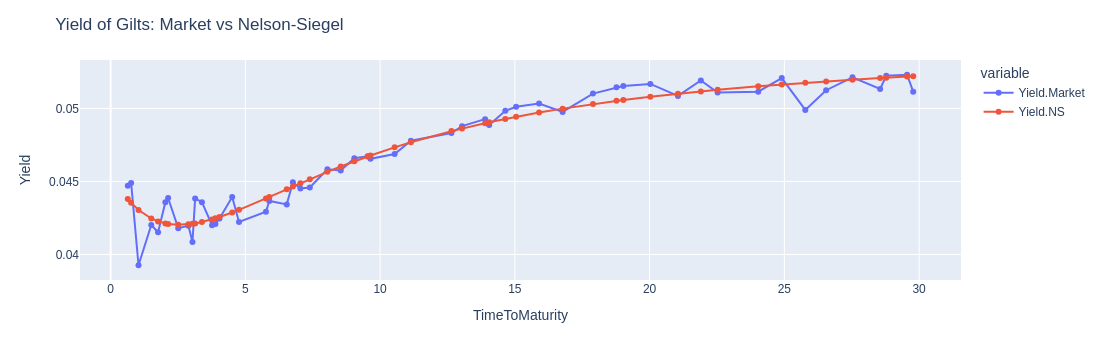

In [130]:
px.line(data_frame=yld_Market_vs_NS, markers=True).update_layout(yaxis_title=yld, title='Yield of Gilts: Market vs Nelson-Siegel')